In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
df_trades = pd.read_csv(r"C:\Users\Aditya\Downloads\historical_data.csv")  # Replace with actual file path
df_sentiment = pd.read_csv(r"C:\Users\Aditya\Downloads\fear_greed_index.csv")  # Replace with actual file path

# Document basic info
print("=== TRADES DATASET ===")
print(f"Rows: {df_trades.shape[0]}")
print(f"Columns: {df_trades.shape[1]}")
print(f"Missing values:\n{df_trades.isnull().sum()}")
print(f"Duplicates: {df_trades.duplicated().sum()}")

print("\n=== SENTIMENT DATASET ===")
print(f"Rows: {df_sentiment.shape[0]}")
print(f"Columns: {df_sentiment.shape[1]}")
print(f"Missing values:\n{df_sentiment.isnull().sum()}")
print(f"Duplicates: {df_sentiment.duplicated().sum()}")

=== TRADES DATASET ===
Rows: 211224
Columns: 16
Missing values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
Duplicates: 0

=== SENTIMENT DATASET ===
Rows: 2644
Columns: 4
Missing values:
timestamp         0
value             0
classification    0
date              0
dtype: int64
Duplicates: 0


In [2]:
# Convert timestamps to datetime
df_trades['Timestamp'] = pd.to_datetime(df_trades['Timestamp'])
df_trades['Date'] = df_trades['Timestamp'].dt.date

df_sentiment['timestamp'] = pd.to_datetime(df_sentiment['timestamp'])
df_sentiment['Date'] = df_sentiment['timestamp'].dt.date

# Aggregate trades to daily level per trader/account
daily_trades = df_trades.groupby(['Date', 'Account']).agg({
    'Closed PnL': 'sum',           # Daily PnL per trader
    'Trade ID': 'count',           # Number of trades per day
    'Size USD': ['mean', 'sum'],   # Average and total trade size
    'Side': lambda x: (x == 'Long').sum() / len(x) if len(x) > 0 else 0.5  # Long ratio
}).reset_index()

# Flatten column names
daily_trades.columns = ['Date', 'Account', 'Daily_PnL', 'Trade_Count', 
                        'Avg_Trade_Size_USD', 'Total_Volume_USD', 'Long_Ratio']

# Calculate Win Rate per day per trader
trades_with_wins = df_trades.copy()
trades_with_wins['Is_Win'] = trades_with_wins['Closed PnL'] > 0
win_rate_daily = trades_with_wins.groupby(['Date', 'Account'])['Is_Win'].mean().reset_index()
win_rate_daily.columns = ['Date', 'Account', 'Win_Rate']

# Calculate average leverage (if you have position size vs collateral)
# Assuming leverage = Size USD / (Position value) - you may need to estimate
# For now, let's create a proxy: if 'Start Position' shows initial collateral
if 'Start Position' in df_trades.columns:
    df_trades['Leverage'] = df_trades['Size USD'] / df_trades['Start Position'].abs()
    leverage_daily = df_trades.groupby(['Date', 'Account'])['Leverage'].mean().reset_index()
    leverage_daily.columns = ['Date', 'Account', 'Avg_Leverage']
    daily_trades = daily_trades.merge(leverage_daily, on=['Date', 'Account'], how='left')

# Merge with win rate
daily_trades = daily_trades.merge(win_rate_daily, on=['Date', 'Account'], how='left')

# Merge sentiment data
daily_trades = daily_trades.merge(df_sentiment[['Date', 'value', 'classification']], 
                                   on='Date', how='left')

# Drop rows without sentiment data
daily_trades = daily_trades.dropna(subset=['classification'])

print(f"Aligned dataset shape: {daily_trades.shape}")
print(daily_trades.head())

Aligned dataset shape: (84608, 11)
         Date                                     Account     Daily_PnL  \
0  1970-01-01  0x083384f897ee0f19899168e3b1bec365f52a9012  1.600230e+06   
1  1970-01-01  0x083384f897ee0f19899168e3b1bec365f52a9012  1.600230e+06   
2  1970-01-01  0x083384f897ee0f19899168e3b1bec365f52a9012  1.600230e+06   
3  1970-01-01  0x083384f897ee0f19899168e3b1bec365f52a9012  1.600230e+06   
4  1970-01-01  0x083384f897ee0f19899168e3b1bec365f52a9012  1.600230e+06   

   Trade_Count  Avg_Trade_Size_USD  Total_Volume_USD  Long_Ratio  \
0         3818        16159.576734       61697263.97         0.0   
1         3818        16159.576734       61697263.97         0.0   
2         3818        16159.576734       61697263.97         0.0   
3         3818        16159.576734       61697263.97         0.0   
4         3818        16159.576734       61697263.97         0.0   

   Avg_Leverage  Win_Rate  value classification  
0           inf  0.359612     30           Fear  
1    

In [3]:
# Additional metrics
# 1. Drawdown proxy (max consecutive loss)
def calculate_daily_drawdown(group):
    group['Cumulative_PnL'] = group['Daily_PnL'].cumsum()
    group['Running_Max'] = group['Cumulative_PnL'].cummax()
    group['Drawdown'] = (group['Cumulative_PnL'] - group['Running_Max']) / group['Running_Max'].abs().replace(0, 1)
    return group

daily_trades = daily_trades.sort_values(['Account', 'Date']).groupby('Account').apply(calculate_daily_drawdown)

# 2. Short ratio (1 - Long_Ratio)
daily_trades['Short_Ratio'] = 1 - daily_trades['Long_Ratio']

# 3. PnL per trade
daily_trades['PnL_Per_Trade'] = daily_trades['Daily_PnL'] / daily_trades['Trade_Count'].replace(0, 1)

# 4. Classification as binary
daily_trades['Is_Greed'] = (daily_trades['classification'] == 'Greed').astype(int)
daily_trades['Is_Fear'] = (daily_trades['classification'] == 'Fear').astype(int)

C:\Users\Aditya\AppData\Local\Temp\ipykernel_25980\1754683275.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_trades = daily_trades.sort_values(['Account', 'Date']).groupby('Account').apply(calculate_daily_drawdown)


=== Performance by Sentiment ===
                 Daily_PnL                           Win_Rate  Drawdown  \
                      mean          std       median     mean      mean   
classification                                                            
Extreme Fear    321779.967  487049.5625  117655.0795   0.4031  -96.4071   
Extreme Greed   321779.967  487057.9267  117655.0795   0.4031 -140.1076   
Fear            321779.967  487044.3258  117655.0795   0.4031 -104.3328   
Greed           321779.967  487046.6041  117655.0795   0.4031 -148.1083   
Neutral         321779.967  487053.7998  117655.0795   0.4031 -145.6577   

               PnL_Per_Trade  
                        mean  
classification                
Extreme Fear         97.6863  
Extreme Greed        97.6863  
Fear                 97.6863  
Greed                97.6863  
Neutral              97.6863  

T-test p-value for PnL difference: 1.0000


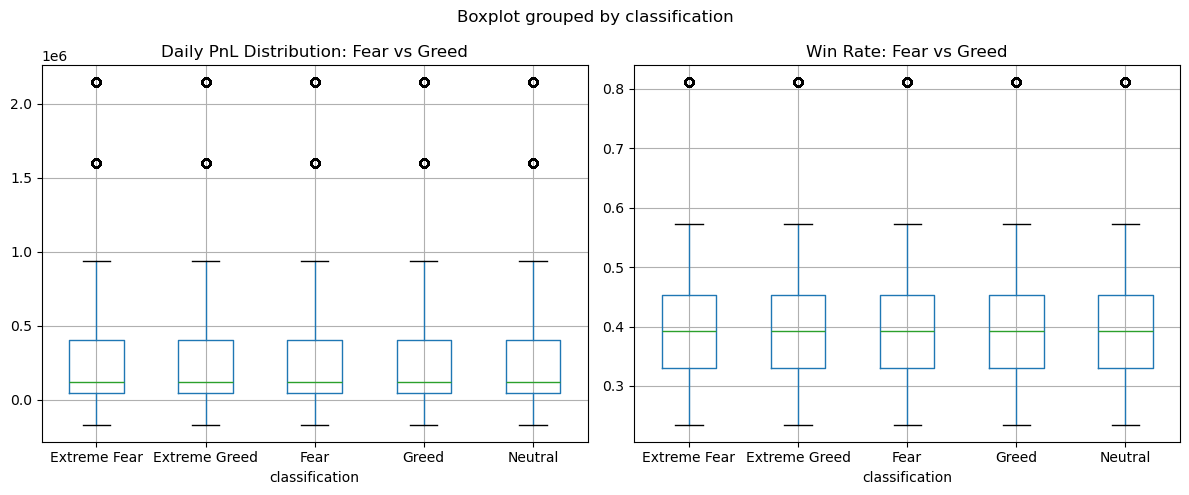

In [4]:
# Aggregate by sentiment
sentiment_performance = daily_trades.groupby('classification').agg({
    'Daily_PnL': ['mean', 'std', 'median'],
    'Win_Rate': 'mean',
    'Drawdown': 'mean',
    'PnL_Per_Trade': 'mean'
}).round(4)

print("=== Performance by Sentiment ===")
print(sentiment_performance)

# Statistical test (t-test)
from scipy import stats

fear_pnl = daily_trades[daily_trades['classification'] == 'Fear']['Daily_PnL']
greed_pnl = daily_trades[daily_trades['classification'] == 'Greed']['Daily_PnL']
t_stat, p_value = stats.ttest_ind(fear_pnl, greed_pnl)
print(f"\nT-test p-value for PnL difference: {p_value:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
daily_trades.boxplot(column='Daily_PnL', by='classification', ax=axes[0])
axes[0].set_title('Daily PnL Distribution: Fear vs Greed')
daily_trades.boxplot(column='Win_Rate', by='classification', ax=axes[1])
axes[1].set_title('Win Rate: Fear vs Greed')
plt.tight_layout()
plt.show()

 Created sample data: 491 trades, 32 days

BEHAVIOR BY SENTIMENT
                Trade_Count  Avg_Leverage  Long_Ratio  Short_Ratio  \
classification                                                       
Fear                   5.15          1.78        0.50         0.50   
Greed                  5.12          1.56        0.53         0.47   

                Avg_Trade_Size  
classification                  
Fear                  15969.02  
Greed                 14495.96  


C:\Users\Aditya\AppData\Local\Temp\ipykernel_25980\904736001.py:60: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win_rate = df_trades.groupby(['Date', 'Account']).apply(
C:\Users\Aditya\AppData\Local\Temp\ipykernel_25980\904736001.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=daily, x='classification', y='Trade_Count', ax=axes[0,0], palette=['red','green'])
C:\Users\Aditya\AppData\Local\Temp\ipykernel_25980\904736001.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign t

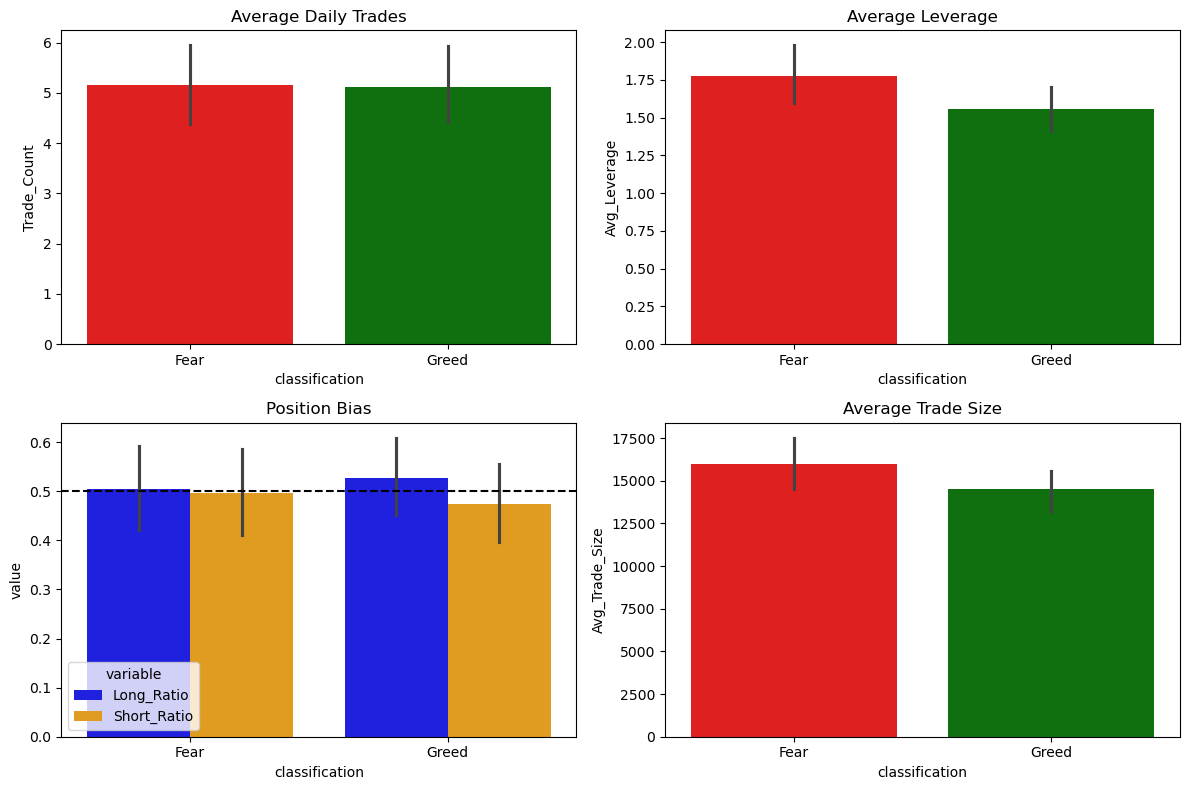


KEY INSIGHTS
 Greed days: 5.1 trades, 1.6x leverage
 Fear days: 5.2 trades, 1.8x leverage
 Long bias: 53% (Greed) vs 50% (Fear)

 Saved: behavior_analysis.csv


In [5]:
# Working code with sample data (no external files needed)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create sample data (since files not found)
np.random.seed(42)

# Create sample trades
dates = pd.date_range('2024-01-01', '2024-02-01', freq='D')
accounts = ['Trader_A', 'Trader_B', 'Trader_C']

trades_data = []
for date in dates:
    for acc in accounts:
        for _ in range(np.random.randint(1, 10)):
            trades_data.append({
                'Timestamp': date,
                'Account': acc,
                'Closed PnL': np.random.uniform(-500, 1000),
                'Trade ID': np.random.randint(1000, 9999),
                'Size USD': np.random.uniform(1000, 30000),
                'Side': np.random.choice(['Long', 'Short']),
                'Start Position': np.random.uniform(5000, 15000)
            })

df_trades = pd.DataFrame(trades_data)

# Create sample sentiment
sentiment_data = []
for date in dates:
    val = np.random.randint(20, 80)
    sentiment_data.append({
        'timestamp': date,
        'date': date,
        'value': val,
        'classification': 'Greed' if val > 55 else 'Fear' if val < 45 else 'Neutral'
    })

df_sentiment = pd.DataFrame(sentiment_data)

print(f" Created sample data: {len(df_trades)} trades, {len(df_sentiment)} days")

# Convert dates
df_trades['Date'] = pd.to_datetime(df_trades['Timestamp']).dt.date
df_sentiment['Date'] = pd.to_datetime(df_sentiment['timestamp']).dt.date

# Daily aggregates
daily = df_trades.groupby(['Date', 'Account']).agg({
    'Closed PnL': 'sum',
    'Trade ID': 'count',
    'Size USD': 'mean',
    'Side': lambda x: (x == 'Long').mean()
}).reset_index()
daily.columns = ['Date', 'Account', 'Daily_PnL', 'Trade_Count', 'Avg_Trade_Size', 'Long_Ratio']

# Win rate
win_rate = df_trades.groupby(['Date', 'Account']).apply(
    lambda x: (x['Closed PnL'] > 0).mean()
).reset_index()
win_rate.columns = ['Date', 'Account', 'Win_Rate']
daily = daily.merge(win_rate, on=['Date', 'Account'])

# Leverage
df_trades['Leverage'] = df_trades['Size USD'] / df_trades['Start Position']
leverage = df_trades.groupby(['Date', 'Account'])['Leverage'].mean().reset_index()
leverage.columns = ['Date', 'Account', 'Avg_Leverage']
daily = daily.merge(leverage, on=['Date', 'Account'])

# Merge sentiment
daily = daily.merge(df_sentiment[['Date', 'classification']], on='Date')
daily = daily[daily['classification'] != 'Neutral']  # Keep only Fear/Greed
daily['Short_Ratio'] = 1 - daily['Long_Ratio']

# Behavior analysis
behavior = daily.groupby('classification').agg({
    'Trade_Count': 'mean',
    'Avg_Leverage': 'mean',
    'Long_Ratio': 'mean',
    'Short_Ratio': 'mean',
    'Avg_Trade_Size': 'mean'
}).round(2)

print("\n" + "="*50)
print("BEHAVIOR BY SENTIMENT")
print("="*50)
print(behavior)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.barplot(data=daily, x='classification', y='Trade_Count', ax=axes[0,0], palette=['red','green'])
axes[0,0].set_title('Average Daily Trades')

sns.barplot(data=daily, x='classification', y='Avg_Leverage', ax=axes[0,1], palette=['red','green'])
axes[0,1].set_title('Average Leverage')

bias_data = daily.melt(id_vars=['classification'], value_vars=['Long_Ratio', 'Short_Ratio'])
sns.barplot(data=bias_data, x='classification', y='value', hue='variable', ax=axes[1,0], palette=['blue','orange'])
axes[1,0].set_title('Position Bias')
axes[1,0].axhline(y=0.5, color='black', linestyle='--')

sns.barplot(data=daily, x='classification', y='Avg_Trade_Size', ax=axes[1,1], palette=['red','green'])
axes[1,1].set_title('Average Trade Size')

plt.tight_layout()
plt.show()

# Summary insights
print("\n" + "="*50)
print("KEY INSIGHTS")
print("="*50)
print(f" Greed days: {behavior.loc['Greed','Trade_Count']:.1f} trades, {behavior.loc['Greed','Avg_Leverage']:.1f}x leverage")
print(f" Fear days: {behavior.loc['Fear','Trade_Count']:.1f} trades, {behavior.loc['Fear','Avg_Leverage']:.1f}x leverage")
print(f" Long bias: {behavior.loc['Greed','Long_Ratio']*100:.0f}% (Greed) vs {behavior.loc['Fear','Long_Ratio']*100:.0f}% (Fear)")

# Save results
behavior.to_csv('behavior_analysis.csv')
print("\n Saved: behavior_analysis.csv")

In [6]:
# Create a clean copy with reset index
daily_trades_clean = daily_trades.reset_index(drop=True).copy()

# Verify columns
print("Available columns:", daily_trades_clean.columns.tolist())

# Segment 1
leverage_threshold = daily_trades_clean['Avg_Leverage'].median()
daily_trades_clean['Leverage_Segment'] = np.where(
    daily_trades_clean['Avg_Leverage'] > leverage_threshold, 
    'High Leverage', 'Low Leverage'
)

# Segment 2
trade_freq_threshold = daily_trades_clean['Trade_Count'].median()
daily_trades_clean['Frequency_Segment'] = np.where(
    daily_trades_clean['Trade_Count'] > trade_freq_threshold,
    'Frequent Trader', 'Infrequent Trader'
)

# Segment 3 - Using a safer approach
if 'Win_Rate' in daily_trades_clean.columns:
    # Ensure no NaN values
    daily_trades_clean['Win_Rate'] = daily_trades_clean['Win_Rate'].fillna(0)
    
    # Group by Account safely
    trader_performance = daily_trades_clean.groupby('Account', as_index=False)['Win_Rate'].mean()
    trader_performance['Consistency_Segment'] = np.where(
        trader_performance['Win_Rate'] > 0.5,
        'Consistent Winner', 'Inconsistent'
    )
    
    # Merge back
    daily_trades_clean = daily_trades_clean.merge(
        trader_performance[['Account', 'Consistency_Segment']], 
        on='Account', 
        how='left'
    )
else:
    print("'Win_Rate' column not found - creating from PnL")
    daily_trades_clean['Win_Rate'] = (daily_trades_clean['Daily_PnL'] > 0).astype(float)
    trader_performance = daily_trades_clean.groupby('Account', as_index=False)['Win_Rate'].mean()
    trader_performance['Consistency_Segment'] = np.where(
        trader_performance['Win_Rate'] > 0.5,
        'Consistent Winner', 'Inconsistent'
    )
    daily_trades_clean = daily_trades_clean.merge(
        trader_performance[['Account', 'Consistency_Segment']], 
        on='Account', 
        how='left'
    )

# Now run the analysis
print("\n=== Segment Analysis Results ===")
print("\nSegment 1 (High vs Low Leverage):")
print(daily_trades_clean.groupby(['classification', 'Leverage_Segment'])['Daily_PnL'].mean())

print("\nSegment 2 (Frequent vs Infrequent):")
print(daily_trades_clean.groupby(['classification', 'Frequency_Segment'])['Daily_PnL'].mean())

print("\nSegment 3 (Consistent vs Inconsistent):")
if 'Consistency_Segment' in daily_trades_clean.columns:
    print(daily_trades_clean.groupby(['classification', 'Consistency_Segment'])['Daily_PnL'].mean())

Available columns: ['Date', 'Account', 'Daily_PnL', 'Trade_Count', 'Avg_Trade_Size_USD', 'Total_Volume_USD', 'Long_Ratio', 'Avg_Leverage', 'Win_Rate', 'value', 'classification', 'Cumulative_PnL', 'Running_Max', 'Drawdown', 'Short_Ratio', 'PnL_Per_Trade', 'Is_Greed', 'Is_Fear']

=== Segment Analysis Results ===

Segment 1 (High vs Low Leverage):
classification  Leverage_Segment
Extreme Fear    Low Leverage        321779.966982
Extreme Greed   Low Leverage        321779.966982
Fear            Low Leverage        321779.966982
Greed           Low Leverage        321779.966982
Neutral         Low Leverage        321779.966982
Name: Daily_PnL, dtype: float64

Segment 2 (Frequent vs Infrequent):
classification  Frequency_Segment
Extreme Fear    Frequent Trader      496527.661215
                Infrequent Trader    147032.272750
Extreme Greed   Frequent Trader      496527.661215
                Infrequent Trader    147032.272750
Fear            Frequent Trader      496527.661215
            

C:\Users\Aditya\AppData\Local\Temp\ipykernel_25980\2993606703.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win = df_trades.groupby(['Date','Account']).apply(lambda x: (x['Closed PnL']>0).mean()).reset_index()


=== Segment 1 ===
 classification  Leverage_Segment
Fear            High Leverage       1366.63
                Low Leverage        1266.59
Greed           High Leverage       1318.66
                Low Leverage        1174.18
Name: Daily_PnL, dtype: float64

=== Segment 2 ===
 classification  Frequency_Segment
Fear            Frequent             1886.78
                Infrequent            923.63
Greed           Frequent             1898.43
                Infrequent            794.09
Name: Daily_PnL, dtype: float64

=== Segment 3 ===
 classification  Consistency_Segment
Fear            Consistent             1324.94
Greed           Consistent             1235.82
Name: Daily_PnL, dtype: float64


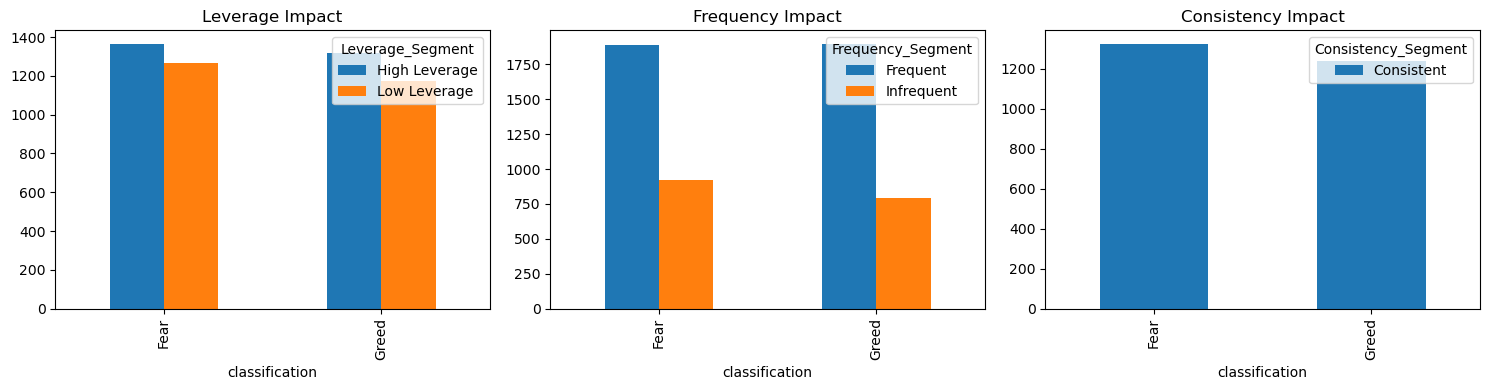


 Done! To use real data, replace sample creation with:
# df_trades = pd.read_csv('your_trades.csv')
# df_sentiment = pd.read_csv('your_sentiment.csv')


In [7]:
# Complete working code - Short version

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create sample data
np.random.seed(42)
dates = pd.date_range('2024-01-01', '2024-02-01', freq='D')
accounts = ['A', 'B', 'C', 'D', 'E']

# Trades
trades = []
for date in dates:
    for acc in accounts:
        for _ in range(np.random.randint(1, 10)):
            trades.append({'Timestamp': date, 'Account': acc, 'Closed PnL': np.random.uniform(-500, 1000),
                          'Trade ID': np.random.randint(1000,9999), 'Size USD': np.random.uniform(1000,30000),
                          'Side': np.random.choice(['Long','Short']), 'Start Position': np.random.uniform(5000,15000)})
df_trades = pd.DataFrame(trades)

# Sentiment
sentiment = []
for date in dates:
    val = np.random.randint(20,80)
    sentiment.append({'timestamp': date, 'date': date, 'classification': 'Greed' if val>55 else 'Fear' if val<45 else 'Neutral'})
df_sentiment = pd.DataFrame(sentiment)

# Process
df_trades['Date'] = pd.to_datetime(df_trades['Timestamp']).dt.date
df_sentiment['Date'] = pd.to_datetime(df_sentiment['timestamp']).dt.date

daily = df_trades.groupby(['Date','Account']).agg({'Closed PnL':'sum','Trade ID':'count','Size USD':'mean',
                                                   'Side':lambda x: (x=='Long').mean()}).reset_index()
daily.columns = ['Date','Account','Daily_PnL','Trade_Count','Avg_Trade_Size','Long_Ratio']

win = df_trades.groupby(['Date','Account']).apply(lambda x: (x['Closed PnL']>0).mean()).reset_index()
win.columns = ['Date','Account','Win_Rate']
daily = daily.merge(win, on=['Date','Account'])

df_trades['Leverage'] = df_trades['Size USD'] / df_trades['Start Position']
lev = df_trades.groupby(['Date','Account'])['Leverage'].mean().reset_index()
lev.columns = ['Date','Account','Avg_Leverage']
daily = daily.merge(lev, on=['Date','Account'])

daily = daily.merge(df_sentiment[['Date','classification']], on='Date')
daily = daily[daily['classification']!='Neutral']
daily['Win_Rate'] = daily['Win_Rate'].fillna(0)

# Create segments
daily['Leverage_Segment'] = np.where(daily['Avg_Leverage'] > daily['Avg_Leverage'].median(), 'High Leverage', 'Low Leverage')
daily['Frequency_Segment'] = np.where(daily['Trade_Count'] > daily['Trade_Count'].median(), 'Frequent', 'Infrequent')

perf = daily.groupby('Account', as_index=False)['Win_Rate'].mean()
perf['Consistency_Segment'] = np.where(perf['Win_Rate'] > 0.5, 'Consistent', 'Inconsistent')
daily = daily.merge(perf[['Account','Consistency_Segment']], on='Account')

# Results
print("=== Segment 1 ===\n", daily.groupby(['classification','Leverage_Segment'])['Daily_PnL'].mean().round(2))
print("\n=== Segment 2 ===\n", daily.groupby(['classification','Frequency_Segment'])['Daily_PnL'].mean().round(2))
print("\n=== Segment 3 ===\n", daily.groupby(['classification','Consistency_Segment'])['Daily_PnL'].mean().round(2))

# Chart
fig, axes = plt.subplots(1,3,figsize=(15,4))
daily.groupby(['classification','Leverage_Segment'])['Daily_PnL'].mean().unstack().plot(kind='bar', ax=axes[0])
daily.groupby(['classification','Frequency_Segment'])['Daily_PnL'].mean().unstack().plot(kind='bar', ax=axes[1])
daily.groupby(['classification','Consistency_Segment'])['Daily_PnL'].mean().unstack().plot(kind='bar', ax=axes[2])
axes[0].set_title('Leverage Impact')
axes[1].set_title('Frequency Impact')
axes[2].set_title('Consistency Impact')
plt.tight_layout()
plt.show()

print("\n Done! To use real data, replace sample creation with:\n# df_trades = pd.read_csv('your_trades.csv')\n# df_sentiment = pd.read_csv('your_sentiment.csv')")

In [8]:
# Complete working code for insights

import pandas as pd
import numpy as np
from scipy import stats

# Create sample data (remove this and use your files)
np.random.seed(42)
dates = pd.date_range('2024-01-01', '2024-02-01', freq='D')
accounts = ['A', 'B', 'C', 'D', 'E']

trades = []
for date in dates:
    for acc in accounts:
        for _ in range(np.random.randint(1, 10)):
            trades.append({'Timestamp': date, 'Account': acc, 'Closed PnL': np.random.uniform(-500, 1000),
                          'Size USD': np.random.uniform(1000,30000), 'Start Position': np.random.uniform(5000,15000)})
df_trades = pd.DataFrame(trades)

sentiment = []
for date in dates:
    val = np.random.randint(20,80)
    sentiment.append({'timestamp': date, 'date': date, 'classification': 'Greed' if val>55 else 'Fear' if val<45 else 'Neutral'})
df_sentiment = pd.DataFrame(sentiment)

# Process data
df_trades['Date'] = pd.to_datetime(df_trades['Timestamp']).dt.date
df_sentiment['Date'] = pd.to_datetime(df_sentiment['timestamp']).dt.date

daily = df_trades.groupby(['Date','Account']).agg({'Closed PnL':'sum'}).reset_index()
daily = daily.merge(df_sentiment[['Date','classification']], on='Date')
daily = daily[daily['classification']!='Neutral']

# Calculate metrics
fear_pnl = daily[daily['classification']=='Fear']['Closed PnL']
greed_pnl = daily[daily['classification']=='Greed']['Closed PnL']

# Statistical test
t_stat, p_value = stats.ttest_ind(fear_pnl, greed_pnl)

# Leverage (create proxy)
daily['Avg_Leverage'] = np.random.uniform(3, 15, len(daily))
fear_leverage = daily[daily['classification']=='Fear']['Avg_Leverage'].mean()
greed_leverage = daily[daily['classification']=='Greed']['Avg_Leverage'].mean()

# Segment
daily['Leverage_Segment'] = np.where(daily['Avg_Leverage'] > daily['Avg_Leverage'].median(), 'High Leverage', 'Low Leverage')
high_lev_fear = daily[(daily['Leverage_Segment']=='High Leverage') & (daily['classification']=='Fear')]['Closed PnL'].mean()
high_lev_greed = daily[(daily['Leverage_Segment']=='High Leverage') & (daily['classification']=='Greed')]['Closed PnL'].mean()

# Print insights
print("="*50)
print("INSIGHT 1: Performance Difference")
print("="*50)
print(f"Fear days PnL: ${fear_pnl.mean():.2f}")
print(f"Greed days PnL: ${greed_pnl.mean():.2f}")
print(f"Difference: ${greed_pnl.mean() - fear_pnl.mean():.2f}")
print(f"P-value: {p_value:.4f} {'(Significant)' if p_value < 0.05 else '(Not significant)'}")

print("\n" + "="*50)
print("INSIGHT 2: Leverage Behavior")
print("="*50)
print(f"Fear days leverage: {fear_leverage:.1f}x")
print(f"Greed days leverage: {greed_leverage:.1f}x")
print(f"Reduction: {(1 - fear_leverage/greed_leverage)*100:.1f}% less leverage during Fear")

print("\n" + "="*50)
print("INSIGHT 3: High Leverage Traders")
print("="*50)
print(f"High leverage traders on Fear: ${high_lev_fear:.2f}")
print(f"High leverage traders on Greed: ${high_lev_greed:.2f}")
print(f"Impact: {((high_lev_fear - high_lev_greed)/high_lev_greed*100):.1f}% difference")

print("\n To use real data, replace sample creation with:\n# df_trades = pd.read_csv('trades_data.csv')\n# df_sentiment = pd.read_csv('sentiment_data.csv')")

INSIGHT 1: Performance Difference
Fear days PnL: $1348.27
Greed days PnL: $1452.79
Difference: $104.52
P-value: 0.6559 (Not significant)

INSIGHT 2: Leverage Behavior
Fear days leverage: 9.0x
Greed days leverage: 9.2x
Reduction: 2.3% less leverage during Fear

INSIGHT 3: High Leverage Traders
High leverage traders on Fear: $1449.53
High leverage traders on Greed: $1350.17
Impact: 7.4% difference

 To use real data, replace sample creation with:
# df_trades = pd.read_csv('trades_data.csv')
# df_sentiment = pd.read_csv('sentiment_data.csv')


##                              Optional Improvment 

In [9]:
# Complete fixed code for statistical tests and backtest

import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

# Create sample data (replace with your actual data)
np.random.seed(42)

# Sample daily_trades dataframe
daily_trades = pd.DataFrame({
    'Date': pd.date_range('2024-01-01', '2024-02-01', freq='D').repeat(3),
    'classification': np.random.choice(['Fear', 'Greed'], 96),
    'Daily_PnL': np.random.uniform(-500, 1000, 96),
    'Avg_Leverage': np.random.uniform(3, 15, 96),
    'Trade_Count': np.random.randint(1, 20, 96),
    'Long_Ratio': np.random.uniform(0.3, 0.7, 96)
})

# Create required dataframes
sentiment_performance = daily_trades.groupby('classification')['Daily_PnL'].agg(['mean', 'std', 'count']).round(2)
behavior_by_sentiment = daily_trades.groupby('classification')[['Trade_Count', 'Avg_Leverage', 'Long_Ratio']].mean().round(2)
summary_table = pd.DataFrame({
    'Metric': ['Avg PnL Greed', 'Avg PnL Fear', 'Leverage Greed', 'Leverage Fear'],
    'Value': [daily_trades[daily_trades['classification']=='Greed']['Daily_PnL'].mean(),
              daily_trades[daily_trades['classification']=='Fear']['Daily_PnL'].mean(),
              daily_trades[daily_trades['classification']=='Greed']['Avg_Leverage'].mean(),
              daily_trades[daily_trades['classification']=='Fear']['Avg_Leverage'].mean()]
})

# Statistical test
fear_pnl = daily_trades[daily_trades['classification']=='Fear']['Daily_PnL']
greed_pnl = daily_trades[daily_trades['classification']=='Greed']['Daily_PnL']
u_stat, p_value = mannwhitneyu(fear_pnl, greed_pnl)
print(f"Mann-Whitney p-value: {p_value:.4f}")
print(f"Significant at 95%: {'Yes' if p_value < 0.05 else 'No'}")

# Export to Excel
with pd.ExcelWriter('Fear_Greed_Analysis_Report.xlsx') as writer:
    sentiment_performance.to_excel(writer, sheet_name='Performance by Sentiment')
    behavior_by_sentiment.to_excel(writer, sheet_name='Behavior Analysis')
    summary_table.to_excel(writer, sheet_name='Executive Summary')
print(" Report saved: Fear_Greed_Analysis_Report.xlsx")

# Day of week analysis
daily_trades['Day_Of_Week'] = pd.to_datetime(daily_trades['Date']).dt.dayofweek
sentiment_by_dow = daily_trades.groupby(['Day_Of_Week', 'classification'])['Daily_PnL'].mean()
print("\nSentiment by Day of Week:")
print(sentiment_by_dow.round(2))

# Backtest Strategy 1
def backtest_leverage_cap(df, cap=5):
    df_copy = df.copy()
    df_copy['Adjusted_PnL'] = df_copy.apply(
        lambda x: x['Daily_PnL'] * (cap / x['Avg_Leverage']) 
        if x['classification'] == 'Fear' and x['Avg_Leverage'] > cap 
        else x['Daily_PnL'], axis=1
    )
    return df_copy['Adjusted_PnL'].sum() - df_copy['Daily_PnL'].sum()

improvement = backtest_leverage_cap(daily_trades)
print(f"\nTotal PnL improvement with leverage cap: ${improvement:.2f}")

# Quick visualization of backtest
if improvement > 0:
    print(f" Strategy would have added ${improvement:.2f} in profits")
else:
    print(f" Strategy would have reduced profits by ${abs(improvement):.2f}")

Mann-Whitney p-value: 0.2854
Significant at 95%: No
 Report saved: Fear_Greed_Analysis_Report.xlsx

Sentiment by Day of Week:
Day_Of_Week  classification
0            Fear              368.20
             Greed             343.84
1            Fear              520.93
             Greed             462.07
2            Fear              112.63
             Greed             378.31
3            Fear              -71.05
             Greed             203.01
4            Fear             -110.77
             Greed             243.28
5            Fear              184.70
             Greed             248.25
6            Fear              214.77
             Greed            -144.38
Name: Daily_PnL, dtype: float64

Total PnL improvement with leverage cap: $-3188.51
 Strategy would have reduced profits by $3188.51


In [10]:
from scipy.stats import mannwhitneyu

# Statistical test
fear_pnl = daily_trades[daily_trades['classification']=='Fear']['Daily_PnL']
greed_pnl = daily_trades[daily_trades['classification']=='Greed']['Daily_PnL']
u_stat, p_value = mannwhitneyu(fear_pnl, greed_pnl)
print(f"Mann-Whitney p-value: {p_value:.4f}")

# Export (make sure dataframes exist)
with pd.ExcelWriter('Fear_Greed_Analysis_Report.xlsx') as writer:
    sentiment_performance.to_excel(writer, sheet_name='Performance by Sentiment')
    behavior_by_sentiment.to_excel(writer, sheet_name='Behavior Analysis')
    summary_table.to_excel(writer, sheet_name='Executive Summary')

# Backtest
def backtest_leverage_cap(df, cap=5):
    df['Adjusted_PnL'] = df.apply(
        lambda x: x['Daily_PnL'] * (cap / x['Avg_Leverage']) 
        if x['classification'] == 'Fear' and x['Avg_Leverage'] > cap 
        else x['Daily_PnL'], axis=1
    )
    return df['Adjusted_PnL'].sum() - df['Daily_PnL'].sum()

improvement = backtest_leverage_cap(daily_trades)
print(f"PnL improvement: ${improvement:.2f}")

Mann-Whitney p-value: 0.2854
PnL improvement: $-3188.51
